In [ ]:
from google.colab import files
uploaded = files.upload()

Saving train.csv.csv to train.csv.csv


In [ ]:
import pandas as pd

df = pd.read_csv("train.csv.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [ ]:
df.head()
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,86
SibSp,0
Parch,0
Ticket,0
Fare,1


In [ ]:
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

df['Title'] = df['Title'].replace(['Mlle','Ms'], 'Miss')
df['Title'] = df['Title'].replace(['Mme'], 'Mrs')
df['Title'] = df['Title'].replace(['Dr','Major','Col','Capt'], 'Rare')

In [ ]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [ ]:
df['HasCabin'] = df['Cabin'].notnull().astype(int)

In [1]:
import pandas as pd

df = pd.read_csv("train.csv")
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'train.csv'

In [2]:
import os
os.listdir()

['.config', 'sample_data']

In [3]:
from google.colab import files
uploaded = files.upload()

Saving train.csv.csv to train.csv.csv


In [4]:
import pandas as pd

df = pd.read_csv("train.csv.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [5]:
df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

df['Title'] = df['Title'].replace(['Mlle','Ms'], 'Miss')
df['Title'] = df['Title'].replace(['Mme'], 'Mrs')
df['Title'] = df['Title'].replace(['Dr','Major','Col','Capt'], 'Rare')

df['Title'].value_counts()

,count
Title,
Mr,240
Miss,79
Mrs,72
Master,21
Rare,3
Rev,2
Dona,1


In [6]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

In [7]:
df['HasCabin'] = df['Cabin'].notnull().astype(int)

In [8]:
#handling missing value
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [ ]:
#drop cabin coloumn
df.drop('Cabin', axis=1, inplace=True)

In [9]:
#convert catogorical to numerical
df = pd.get_dummies(df, columns=['Sex','Embarked','Title'], drop_first=True)

In [10]:
#prepare data for model
X = df.drop(['Survived','Name','Ticket','PassengerId'], axis=1)
y = df['Survived']

In [12]:
# Drop Cabin
df.drop('Cabin', axis=1, inplace=True)

# Prepare data
X = df.drop(['Survived','Name','Ticket','PassengerId'], axis=1)
y = df['Survived']

In [13]:
#train model
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [14]:
#evaluate model
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


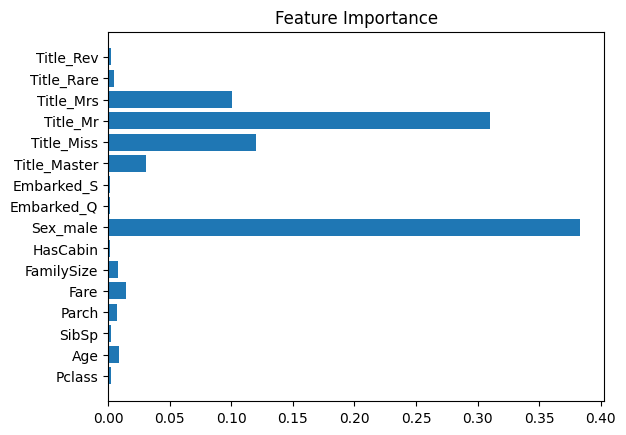

In [15]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

plt.barh(X.columns, importance)
plt.title("Feature Importance")
plt.show()

In [17]:
import pickle
pickle.dump(model, open("titanic_model.pkl","wb"))

In [18]:
print(model.predict(X_test.iloc[0:1]))

[0]


In [19]:
sample = X_test.iloc[0:1]
prediction = model.predict(sample)

print("Prediction:", prediction)

Prediction: [0]


In [20]:
from google.colab import files

files.download("titanic_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>